<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/ShortestPath-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [3]:
import pandas as pd
import json
import os
import glob

Set the Path to the Data location (imported form SharpHound)

# Set the Path
to the Data location (imported from SharpHound) and Read json files in folder and create a dictionary with the entire data.





In [4]:
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json

!mkdir = "/content/adsync"
#!mv secure.json /content/adsync
!mv secure10k.json /content/adsync

path = "/content/adsync"
data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-07-23 19:23:46--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14606414 (14M) [text/plain]
Saving to: ‘secure10k.json’

secure10k.json      100%[===================>]  13.93M  --.-KB/s    in 0.1s    

2025-07-23 19:23:46 (122 MB/s) - ‘secure10k.json’ saved [14606414/14606414]



Show the "content"

In [5]:
#content


In [6]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges

import pandas as pd
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [7]:
# prompt: show all rows


pd.set_option('display.max_rows', None)



In [8]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))


In [9]:
# prompt: remove the following columns from nodes:
# start, end, label

nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])


In [10]:

edges = edges.drop(columns=['labels'])


Expand "Properties" column in new columns.

Convert to Dict

In [11]:
pd.set_option("display.max_rows", None, "display.max_columns", None)

#nodes

In [12]:
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')


In [13]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# nodes_json = nodes.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('nodes.json', 'w') as f:
#   f.write(nodes_json)


In [14]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# edges_json = edges.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('edges.json', 'w') as f:
#   f.write(edges_json)

In [15]:
# prompt: create a new column in nodes called weight

nodes['weight'] = 1

In [65]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

nodes.tail()

,id,properties,type,l1,l2,l3,weight
10070,16291,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder198_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10923', 'distinguishedname': 'CN=T2_HR_FOLDER198_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': 'False', 'admincount': 'False', 'owned': 'False'}",node,Base,Group,None,1
10071,16292,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder199_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10924', 'distinguishedname': 'CN=T2_HR_FOLDER199_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': 'False', 'admincount': 'False', 'owned': 'False'}",node,Base,Group,None,1
10072,16293,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder200_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10925', 'distinguishedname': 'CN=T2_HR_FOLDER200_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': 'False', 'admincount': 'False', 'owned': 'False'}",node,Base,Group,None,1
10073,16294,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder201_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10926', 'distinguishedname': 'CN=T2_HR_FOLDER201_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': 'False', 'admincount': 'False', 'owned': 'False'}",node,Base,Group,None,1
10074,16295,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder202_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-10927', 'distinguishedname': 'CN=T2_HR_FOLDER202_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': 'False', 'admincount': 'False', 'owned': 'False'}",node,Base,Group,None,1


In [17]:
# 1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0']
        )
    )
]['id'].tolist()


tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    )
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']
        )
    )
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))

tier 0  516
tier 1  701
tier 2  8933


In [66]:
# prompt: find records from nodes where distinguishedname has "CN=Enterprise Admins," or  distinguishedname has "CN=Domain Admins,"  then append id to tier0_node_ids if not already present

# Assuming 'nodes' DataFrame is already defined from the preceding code

# Initialize an empty list to store the IDs
#tier0_node_ids = []

# Iterate through each row of the 'nodes' DataFrame
for index, row in nodes.iterrows():
    properties = row['properties']
    node_id = row['id']

    # Check if 'properties' is a dictionary and contains 'distinguishedname'
    if isinstance(properties, dict) and 'distinguishedname' in properties:
        distinguishedname = properties['distinguishedname']

        # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
        if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname:
            # Append the id if it's not already in the list
            if node_id not in tier0_node_ids:
                tier0_node_ids.append(node_id)

print(f"tier 0 (including 'CN=Enterprise Admins,' or 'CN=Domain Admins,'): {len(tier0_node_ids)}")
# The existing prints for tier1 and tier2 will remain the same
print(f"tier 1 : {len(tier1_node_ids)}")
print(f"tier 2 : {len(tier2_node_ids)}")
print("Tier 0 Node IDs:", tier0_node_ids)

tier 0 (including 'CN=Enterprise Admins,' or 'CN=Domain Admins,'): 518
tier 1 : 701
tier 2 : 8933
Tier 0 Node IDs: [6225, 6228, 6229, 6230, 6231, 6373, 6374, 6375, 6376, 6377, 6378, 6381, 6387, 6389, 6390, 6401, 6406, 6409, 6412, 6416, 6424, 6425, 6429, 6430, 6431, 6433, 6434, 6437, 6438, 6445, 6446, 6447, 6450, 6452, 6458, 6459, 6460, 6461, 6462, 6463, 6465, 6467, 6469, 6471, 6476, 6478, 6482, 6483, 6484, 6485, 6490, 6497, 6502, 6503, 6509, 6510, 6511, 6512, 6515, 6520, 6529, 6530, 6534, 6536, 6538, 6540, 6542, 6544, 6546, 6550, 6551, 6559, 6563, 6564, 6568, 6572, 6574, 6576, 6578, 6579, 6587, 6593, 6595, 6597, 6603, 6604, 6608, 6609, 6610, 6612, 6615, 6616, 6622, 6628, 6633, 6635, 6640, 6643, 6651, 6652, 6660, 6664, 6671, 6674, 6678, 6679, 6684, 6686, 6688, 6689, 6697, 6698, 6699, 6704, 6781, 6800, 6801, 6824, 6826, 6830, 6838, 6858, 6862, 6902, 6956, 6978, 6982, 7003, 7009, 7012, 7076, 7094, 7104, 7144, 7157, 7167, 7188, 7210, 7233, 7237, 7255, 7278, 7282, 7295, 7301, 7329, 7331, 73

In [67]:
# prompt: show me the last 5 entries in tier0_node_ids

print(tier0_node_ids[-5:])

[12953, 12971, 12977, 6290, 6291]


In [69]:
# prompt: find records from nodes where 'admincount' = True and 'highvalue' = True and  (distinguishedname has "T0" or "Tier 0" or "TIER 0")

# Filter nodes based on conditions
filtered_node = nodes[
    nodes['properties'].apply(
        lambda x: x.get('admincount', False) == True and
                  x.get('highvalue', False) == True and
                  any(term in x.get('distinguishedname', '') for term in ["T0", "Tier 0", "TIER 0"])
    )
]

# Display the filtered nodes
print("Records where 'admincount' and 'highvalue' are True, and distinguishedname contains 'T0', 'Tier 0', or 'TIER 0':")

filtered_node

Records where 'admincount' and 'highvalue' are True, and distinguishedname contains 'T0', 'Tier 0', or 'TIER 0':


,id,properties,type,l1,l2,l3,weight


In [91]:
len(tier0_node_ids)

518

In [99]:
# prompt: find records from nodes where "objectid" ends with match(r'.*-\d{3}$' and highvalue=true and admincount=true.

import re

# Filter nodes where 'objectid' ends with a dash followed by exactly three digits,
# 'highvalue' is True, and 'admincount' is True.
filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-\d{3}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == "True" and
                  x.get('admincount', False) == "True"
    )
]

# Display the filtered nodes
print("Records where 'objectid' ends with - followed by three digits, and 'highvalue' and 'admincount' are True:")
filtered_nodes

Records where 'objectid' ends with - followed by three digits, and 'highvalue' and 'admincount' are True:


,id,properties,type,l1,l2,l3,weight
40,6261,"{'domain': 'TESTLAB.LOCALE', 'name': 'ADMINISTRATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-544', 'highvalue': 'True', 'distinguishedname': 'CN=Administrators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Administrators have complete and unrestricted access to the computer/domain', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
42,6263,"{'domain': 'TESTLAB.LOCALE', 'name': 'PRINT OPERATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-550', 'highvalue': 'True', 'distinguishedname': 'CN=Print Operators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Members can administer printers installed on domain controllers', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
44,6265,"{'domain': 'TESTLAB.LOCALE', 'name': 'BACKUP OPERATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-551', 'highvalue': 'True', 'distinguishedname': 'CN=Backup Operators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Backup Operators can override security restrictions for the sole purpose of backing up or restoring files', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
63,6284,"{'domain': 'TESTLAB.LOCALE', 'name': 'SERVER OPERATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-549', 'highvalue': 'True', 'distinguishedname': 'CN=Server Operators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Members can administer domain servers', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
64,6285,"{'domain': 'TESTLAB.LOCALE', 'name': 'ACCOUNT OPERATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-548', 'highvalue': 'True', 'distinguishedname': 'CN=Account Operators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Members can administer domain user and group accounts', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
69,6290,"{'domain': 'TESTLAB.LOCALE', 'name': 'ENTERPRISE ADMINS@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-519', 'highvalue': 'True', 'distinguishedname': 'CN=Enterprise Admins,CN=Users,DC=TESTLAB,DC=LOCALE', 'description': 'Designated administrators of the enterprise', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
70,6291,"{'domain': 'TESTLAB.LOCALE', 'name': 'DOMAIN ADMINS@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-512', 'highvalue': 'True', 'distinguishedname': 'CN=Domain Admins,CN=Users,DC=TESTLAB,DC=LOCALE', 'description': 'Designated administrators of the domain', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1
76,6297,"{'domain': 'TESTLAB.LOCALE', 'name': 'DOMAIN CONTROLLERS@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-516', 'highvalue': 'True', 'distinguishedname': 'CN=Domain Controllers,CN=Users,DC=TESTLAB,DC=LOCALE', 'description': 'All domain controllers in the domain', 'admincount': 'True', 'owned': 'False'}",node,Base,Group,None,1


In [107]:
# prompt:  check if "id" from filtered_nodes is in tier0_node_ids, if not then append to tier0_node_ids

# Assuming filtered_nodes DataFrame is already defined from the preceding code

# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")
print("Updated Tier 0 Node IDs:", tier0_node_ids)


tier 0 (after checking filtered_nodes): 524
Updated Tier 0 Node IDs: [np.int64(6225), 6228, 6229, 6230, 6231, 6373, 6374, 6375, 6376, 6377, 6378, 6381, 6387, 6389, 6390, 6401, 6406, 6409, 6412, 6416, 6424, 6425, 6429, 6430, 6431, 6433, 6434, 6437, 6438, 6445, 6446, 6447, 6450, 6452, 6458, 6459, 6460, 6461, 6462, 6463, 6465, 6467, 6469, 6471, 6476, 6478, 6482, 6483, 6484, 6485, 6490, 6497, 6502, 6503, 6509, 6510, 6511, 6512, 6515, 6520, 6529, 6530, 6534, 6536, 6538, 6540, 6542, 6544, 6546, 6550, 6551, 6559, 6563, 6564, 6568, 6572, 6574, 6576, 6578, 6579, 6587, 6593, 6595, 6597, 6603, 6604, 6608, 6609, 6610, 6612, 6615, 6616, 6622, 6628, 6633, 6635, 6640, 6643, 6651, 6652, 6660, 6664, 6671, 6674, 6678, 6679, 6684, 6686, 6688, 6689, 6697, 6698, 6699, 6704, 6781, 6800, 6801, 6824, 6826, 6830, 6838, 6858, 6862, 6902, 6956, 6978, 6982, 7003, 7009, 7012, 7076, 7094, 7104, 7144, 7157, 7167, 7188, 7210, 7233, 7237, 7255, 7278, 7282, 7295, 7301, 7329, 7331, 7335, 7341, 7345, 7346, 7373, 7381, 74

In [108]:
# prompt: CHANGE THE VALUES OF tier0_node_ids TO INT64

import numpy as np
tier0_node_ids = np.array(tier0_node_ids, dtype=np.int64)
print("Data type of tier0_node_ids:", tier0_node_ids.dtype)

Data type of tier0_node_ids: int64


In [111]:
# prompt: sort tier0_node_ids ascending

import numpy as np
tier0_node_ids = np.sort(tier0_node_ids)

# print("Sorted Tier 0 Node IDs:", tier0_node_ids)
# print("Data type of tier0_node_ids after sorting:", tier0_node_ids.dtype)
# print(f"tier 0 count (after sorting): {len(tier0_node_ids)}")
# print(tier0_node_ids[-5:])

Sorted Tier 0 Node IDs: [ 6225  6228  6229  6230  6231  6261  6263  6265  6284  6285  6290  6291
  6297  6373  6374  6375  6376  6377  6378  6381  6387  6389  6390  6401
  6406  6409  6412  6416  6424  6425  6429  6430  6431  6433  6434  6437
  6438  6445  6446  6447  6450  6452  6458  6459  6460  6461  6462  6463
  6465  6467  6469  6471  6476  6478  6482  6483  6484  6485  6490  6497
  6502  6503  6509  6510  6511  6512  6515  6520  6529  6530  6534  6536
  6538  6540  6542  6544  6546  6550  6551  6559  6563  6564  6568  6572
  6574  6576  6578  6579  6587  6593  6595  6597  6603  6604  6608  6609
  6610  6612  6615  6616  6622  6628  6633  6635  6640  6643  6651  6652
  6660  6664  6671  6674  6678  6679  6684  6686  6688  6689  6697  6698
  6699  6704  6781  6800  6801  6824  6826  6830  6838  6858  6862  6902
  6956  6978  6982  7003  7009  7012  7076  7094  7104  7144  7157  7167
  7188  7210  7233  7237  7255  7278  7282  7295  7301  7329  7331  7335
  7341  7345  7346  7373  7

In [101]:
filtered_nodes.dtypes

,0
id,int64
properties,object
type,object
l1,object
l2,object
l3,object
weight,int64


In [22]:
nodes.keys()


Index(['id', 'properties', 'type', 'l1', 'l2', 'l3', 'weight'], dtype='object')

In [112]:
len(tier0_node_ids)

524

In [18]:
len(nodes)

10075

In [113]:

for value in tier0_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5

#nodes.head(50)

In [115]:
# prompt: get a unique list of label from edges and save it to list called edges_labels

edges_labels = edges['label'].unique().tolist()
edges_labels

['Contains',
 'GpLink',
 'GenericAll',
 'MemberOf',
 'GenericWrite',
 'WriteDacl',
 'Owns',
 'WriteOwner',
 'GetChanges',
 'GetChangesAll',
 'AllExtendedRights',
 'AdminTo',
 'HasSession',
 'AllowedToDelegate',
 'ReadLAPSPassword',
 'CanRDP',
 'ExecuteDCOM',
 'AllowedToAct',
 'CanPSRemote',
 'ForceChangePassword',
 'AddMember',
 'AddSelf']

In [116]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head(50)
#clear_output()


Edges_all DataFrame with weight column:


In [117]:
# prompt: from edges['start'] get 'id' and from edges['end] get 'id'
# replace start with edges['start'][id'] and  end with edges['end']['id']

edges['start'] = edges['start'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges['end'] = edges['end'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)

In [118]:
len(edges)

48321

In [119]:
print("\nEdges_all DataFrame with weight column:")
edges.tail(50)


Edges_all DataFrame with weight column:


,id,properties,type,start,end,label,weight
58346,48271,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,6261,6232,WriteOwner,7
58347,48272,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,6261,6236,WriteOwner,7
58348,48273,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,6261,6235,WriteOwner,7
58349,48274,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,6261,6239,WriteOwner,7
58350,48275,"{'isacl': True, 'isInherited': True, 'inheritanceType': 'All'}",relationship,6261,6245,WriteOwner,7
58351,48276,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,6291,6323,WriteOwner,7
58352,48277,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,6290,6323,WriteOwner,7
58353,48278,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,6285,6229,GenericAll,9
58354,48279,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,6285,6233,GenericAll,9
58355,48280,"{'isacl': True, 'isInherited': False, 'inheritanceType': 'All'}",relationship,6285,6237,GenericAll,9


In [120]:

edges = edges.drop(columns=['properties', 'id'])

In [121]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')
edges.head()
edges['id'].dtype

dtype('int64')

In [122]:
# prompt: create a unique id for each row, make sure it is of type int64

import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')

In [123]:

edges.keys()

Index(['type', 'start', 'end', 'label', 'weight', 'id'], dtype='object')

In [124]:
edges.head()

,type,start,end,label,weight,id
10075,relationship,6221,6222,Contains,2,0
10076,relationship,6221,6223,Contains,2,1
10077,relationship,6221,6224,Contains,2,2
10078,relationship,6222,6225,Contains,2,3
10079,relationship,6222,6226,Contains,2,4


In [127]:
# prompt: make edges['start'] and edges['end'] int64

edges['start'] = edges['start'].astype('int64')
edges['end'] = edges['end'].astype('int64')

In [129]:
# prompt: filter where edges['id'] = tier2_node_ids and call the dataframe selected_ddges

selected_edges = edges[edges['end'].isin(tier0_node_ids)]
len(selected_edges)

1690

In [130]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48321 entries, 10075 to 58395
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    48321 non-null  object
 1   start   48321 non-null  int64 
 2   end     48321 non-null  int64 
 3   label   48321 non-null  object
 4   weight  48321 non-null  int64 
 5   id      48321 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 2.6+ MB


In [131]:
# prompt: selected_edges_t0 = edges[edges['end'].isin(tier0_node_ids)] and selected_edges_t0=edges[edges'start'] is not in tier0_node_ids

selected_edges_t0 = edges[
    (edges['end'].isin(tier0_node_ids))
#    & (~edges['start'].isin(tier0_node_ids))
]
len(selected_edges_t0)

1690

In [132]:
selected_edges_t1 = edges[edges['start'].isin(tier1_node_ids)]
#selected_edges_t1
selected_edges_t2 = edges[edges['start'].isin(tier2_node_ids)]
#selected_edges_t2

In [133]:
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]

In [134]:
len(selected_nodes)

8933

In [135]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['start'], row['end'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier0_node_ids
    }
    for source, paths in shortest_paths.items()
}

# Print the shortest paths (optional)
for source, paths in shortest_paths_filtered.items():
  if paths:
    #print(f"Shortest paths from node {source}:")
    for target, path in paths.items():
        #print(f"  To node {target}: {path}")
        ShortestPath = source, target, path
       # print(ShortestPath)

In [136]:
# prompt: show only records where shortest_paths_filtered is not empty. Sort by source

import pandas as pd
# Convert the dictionary to a list of dictionaries
data_list = []
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        data_list.append({'source': source, 'target': target, 'path': path})

# Create a DataFrame from the list of dictionaries
shortest_paths_df = pd.DataFrame(data_list)

# Filter out records where the 'path' is empty (which implies shortest_paths_filtered is not empty for that source-target pair)
# Since we constructed the DataFrame only from non-empty paths, this step is redundant based on the previous loop,
# but it's good practice if the filtering logic changed.
# A more direct way to check for non-empty paths after DataFrame creation would involve examining the 'path' column length.
# However, the current structure of `data_list` creation ensures that only non-empty paths are included.

# Sort by 'source'
shortest_paths_df_sorted = shortest_paths_df.sort_values(by='source')

# Print the resulting DataFrame
#shortest_paths_df_sorted

In [39]:
#shortest_paths_filtered

In [137]:
# prompt: using the above code, save all ShortestPath to a json file

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': source,
                'target': target,
                'path': path,
            })

with open('shortest_paths.json', 'w') as f:
    json.dump(shortest_paths_list, f, indent=4)

print("Shortest paths saved to shortest_paths.json")


Shortest paths saved to shortest_paths.json


In [138]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_edges_json = selected_edges_t2.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_edges_t2.json', 'w') as f:
  f.write(selected_edges_json)

In [139]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_nodes_json = selected_nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_nodes.json', 'w') as f:
  f.write(selected_nodes_json)

In [140]:
# prompt: export shortest_paths_filtered to json and save as shortest_paths_filtered_json

shortest_paths_filtered_json = json.dumps(ShortestPath, indent=2)

# Optionally, save the JSON string to a file
with open('ShortestPath.json', 'w') as f:
  f.write(shortest_paths_filtered_json)

In [141]:
# prompt: find the corresponding record in edges where (edges['start']=shortest_paths_list['source']) and (edges['end']=shortest_paths_list['target'] and then add up the weight

# Calculate the total weight for each shortest path
shortest_paths_with_weight = []
for path_info in shortest_paths_list:
    total_weight = 0
    # The path is a list of node IDs
    path = path_info['path']
    # Iterate through the path to get the edges
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        # Find the corresponding edge in the 'edges' DataFrame
        # There might be multiple edges between two nodes, so we sum up weights if needed
        # For shortest path, we typically consider the direct edge weight
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            # Assuming there is only one edge with this start and end for simplicity in path finding
            # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
            total_weight += edge.iloc[0]['weight']
    path_info['total_weight'] = total_weight
    shortest_paths_with_weight.append(path_info)

# Print or use the shortest_paths_with_weight list
#for path_info in shortest_paths_with_weight:
 #   print(f"Path from {path_info['source']} to {path_info['target']}: {path_info['path']} - Total Weight: {path_info['total_weight']}")


In [142]:
# prompt: convert shortest_paths_with_weight to dataframe called df_shortest_paths_with_weight

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [148]:
df_filtered_paths.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [150]:
# prompt: show me df_filtered_paths where source is in tier2_node_ids and target is in tier0_node_ids

df_filtered_paths = df_shortest_paths_with_weight[
    (df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids))
]

df_filtered_paths

,source,target,path,total_weight
0,6236,6433,"[6236, 6433]",2
1,6236,6452,"[6236, 6452]",2
2,6236,6458,"[6236, 6458]",2
3,6236,6534,"[6236, 6534]",2
4,6236,6684,"[6236, 6684]",2
5,6239,6686,"[6239, 6686]",2
6,6247,6781,"[6247, 6781]",2
7,6247,6800,"[6247, 6800]",2
8,6247,6801,"[6247, 6801]",2
9,6247,6826,"[6247, 6826]",2


In [147]:
# prompt: from df_shortest_paths_with_weight find the min and max weight, source target and path. only include paths where the source is not in tier0_node_ids and target is in tier0_node_ids

df_filtered_paths = df_shortest_paths_with_weight[
    (~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids))
].copy()

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()] and df_filtered_paths.loc[df_filtered_paths['weight' not equal to 10]]
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]

    print("Min Weight Path:")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    print("\nMax Weight Path:")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (ipython-input-147-3389502290.py, line 9)

In [145]:
print(nodes[nodes['id'] == 12974])
print(nodes[nodes['id'] == 6490])
print(nodes[nodes['id'] == 6229])
#print(nodes[nodes['id'] == 6229])
print(nodes[nodes['id'] == 9723])
print(nodes[nodes['id'] == 6509])
print(nodes[nodes['id'] == 6291])
print(nodes[nodes['id'] == 6261])

         id  \
6753  12974   

                                                                                                                                                                                                                                                                             properties  \
6753  {'domain': 'TESTLAB.LOCALE', 'name': 'T1 DEFAULT Application SERVER@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-7614', 'owned': 'False', 'distinguishedname': 'CN=T1 DEFAULT APPLICATION SERVER,OU=Application,OU=Tier 1 Servers,DC=TESTLAB,DC=LOCALE'}   

      type    l1        l2    l3  weight  
6753  node  Base  Computer  None      10  
       id  \
269  6490   

                                                                                                                                                                                                                                                                                                 

In [48]:
min_weight_row

,2142
source,6335
target,6229
path,"[6335, 6229]"
total_weight,1


In [49]:
# prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]
    print("\nMax Weight Path (with edge weights):")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    path = max_weight_row['path']
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Max Weight Path (with edge weights):
  Source: 6290
  Target: 6452
  Path: [6290, 6229, 9924, 6452]
  Weight: 20
    Edge from 6290 to 6229 (Label: GenericAll): Weight = 9
    Edge from 6229 to 9924 (Label: Contains): Weight = 2
    Edge from 9924 to 6452 (Label: HasSession): Weight = 9


In [52]:
print(nodes[nodes['id'] == 6290])
print(nodes[nodes['id'] == 6229])
print(nodes[nodes['id'] == 9924])
print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

      id  \
69  6290   

                                                                                                                                                                                                                                                                                                                             properties  \
69  {'domain': 'TESTLAB.LOCALE', 'name': 'ENTERPRISE ADMINS@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-519', 'highvalue': True, 'distinguishedname': 'CN=Enterprise Admins,CN=Users,DC=TESTLAB,DC=LOCALE', 'description': 'Designated administrators of the enterprise', 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
69  node  Base  Group  None       1  
     id  \
8  6229   

                                                                                                                                                                                                                     

In [50]:
 #prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    #min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    print("\nMin Weight Path (with edge weights):")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    path = min_weight_row['path']
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Min Weight Path (with edge weights):
  Source: 6335
  Target: 6229
  Path: [6335, 6229]
  Weight: 1
    Edge from 6335 to 6229 (Label: GpLink): Weight = 1


In [51]:
print(nodes[nodes['id'] == 6335])
print(nodes[nodes['id'] == 6229])
# print(nodes[nodes['id'] == 869])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

       id  \
114  6335   

                                                                                                                                                                               properties  \
114  {'domain': 'TESTLAB.LOCALE', 'name': 'PAW Configuration@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-91ce51b5-fabb-4ebc-9df9-74f19df3da3a', 'owned': False}   

     type    l1   l2    l3  weight  
114  node  Base  GPO  None       1  
     id  \
8  6229   

                                                                                                                                                                                                                                                                                                                  properties  \
8  {'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin Devices@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-3dd2e1a2-11ee-49c1-a49a-69921dadcc57', 'distingui

In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight
min_total_weight = df_shortest_paths_with_weight['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
df_min_weight_paths


Paths with the Minimum Total Weight:


,source,target,path,total_weight
866,6308,6319,"[6308, 6319]",1
867,6380,6322,"[6380, 6322]",1
868,6382,6321,"[6382, 6321]",1
869,6383,6320,"[6383, 6320]",1
870,6384,6322,"[6384, 6322]",1
871,6385,6321,"[6385, 6321]",1
872,6386,6321,"[6386, 6321]",1
873,6393,6321,"[6393, 6321]",1
874,6396,6320,"[6396, 6320]",1
875,6397,6322,"[6397, 6322]",1


In [ ]:
# prompt: filter df_shortest_paths_with_weight where start is not in tier0_node_ids

df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)]
df_filtered

,source,target,path,total_weight
0,6236,12979,"[6236, 12979]",2
1,6236,6382,"[6236, 6382]",2
2,6236,6383,"[6236, 6383]",2
3,6236,6385,"[6236, 6385]",2
4,6236,6386,"[6236, 6386]",2
5,6236,6393,"[6236, 6393]",2
6,6236,6396,"[6236, 6396]",2
7,6236,6399,"[6236, 6399]",2
8,6236,6407,"[6236, 6407]",2
9,6236,6411,"[6236, 6411]",2


In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

min_total_weight = df_filtered['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
#df_min_weight_paths


Paths with the Minimum Total Weight:


In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

max_total_weight = df_filtered['total_weight'].max()
# Filter the DataFrame to get rows with the minimum total weight
df_max_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == max_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Maximum Total Weight:")
#df_max_weight_paths


Paths with the Maximum Total Weight:


In [ ]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
path_value_counts = Counter(item for sublist in df_max_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
sorted_path_value_counts = dict(sorted(path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")



Counts of values in paths (sorted in descending order):
Value: 6285, Count: 16
Value: 6229, Count: 16
Value: 9723, Count: 16
Value: 6509, Count: 16
Value: 6291, Count: 16
Value: 6261, Count: 16
Value: 6221, Count: 16
Value: 9842, Count: 1
Value: 6572, Count: 1
Value: 10001, Count: 1
Value: 6497, Count: 1
Value: 10337, Count: 1
Value: 6559, Count: 1
Value: 10340, Count: 1
Value: 6476, Count: 1
Value: 10505, Count: 1
Value: 6412, Count: 1
Value: 10565, Count: 1
Value: 6615, Count: 1
Value: 10645, Count: 1
Value: 6378, Count: 1
Value: 10922, Count: 1
Value: 6463, Count: 1
Value: 11133, Count: 1
Value: 6563, Count: 1
Value: 11197, Count: 1
Value: 6633, Count: 1
Value: 11248, Count: 1
Value: 6389, Count: 1
Value: 11370, Count: 1
Value: 6530, Count: 1
Value: 12334, Count: 1
Value: 6542, Count: 1
Value: 12375, Count: 1
Value: 6595, Count: 1
Value: 12913, Count: 1
Value: 6674, Count: 1
Value: 12974, Count: 1
Value: 6490, Count: 1


In [ ]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
min_path_value_counts = Counter(item for sublist in df_min_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
min_sorted_path_value_counts = dict(sorted(min_path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in min_sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")


Counts of values in paths (sorted in descending order):
Value: 6317, Count: 37
Value: 6319, Count: 33
Value: 6321, Count: 32
Value: 6315, Count: 32
Value: 6285, Count: 28
Value: 6291, Count: 24
Value: 6320, Count: 23
Value: 6316, Count: 23
Value: 6263, Count: 20
Value: 6322, Count: 19
Value: 6318, Count: 19
Value: 6284, Count: 15
Value: 6371, Count: 9
Value: 6297, Count: 4
Value: 6290, Count: 2
Value: 6261, Count: 2
Value: 6229, Count: 2
Value: 6230, Count: 2
Value: 6308, Count: 1
Value: 6380, Count: 1
Value: 6382, Count: 1
Value: 6383, Count: 1
Value: 6384, Count: 1
Value: 6385, Count: 1
Value: 6386, Count: 1
Value: 6393, Count: 1
Value: 6396, Count: 1
Value: 6397, Count: 1
Value: 6399, Count: 1
Value: 6400, Count: 1
Value: 6407, Count: 1
Value: 6411, Count: 1
Value: 6413, Count: 1
Value: 6417, Count: 1
Value: 6419, Count: 1
Value: 6422, Count: 1
Value: 6428, Count: 1
Value: 6433, Count: 1
Value: 6439, Count: 1
Value: 6442, Count: 1
Value: 6443, Count: 1
Value: 6448, Count: 1
Value: 

In [ ]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_max_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
9842,1
10001,1
10337,1
10340,1
10505,1
10565,1
10645,1
10922,1
11133,1


In [ ]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_min_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
6371,9
6525,1
6515,1
6514,1
6513,1
6512,1
6511,1
6510,1
6509,1


In [ ]:
# prompt: nodes['id']=869

print(nodes.loc[nodes['id'] == 6317])
print(nodes.loc[nodes['id'] == 135])


      id  \
96  6317   

                                                                                                                                                                                                                                                                                                        properties  \
96  {'domain': 'TESTLAB.LOCALE', 'name': 'T1 Server Management@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1002', 'distinguishedname': 'CN=T1 SERVER MANAGEMENT,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': True, 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
96  node  Base  Group  None      10  
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight]
Index: []


In [ ]:
# prompt: df_min_weight_paths dtype

df_min_weight_paths.dtypes

#df_max_weight_paths.dtypes

,0
source,int64
target,int64
path,object
total_weight,int64


In [ ]:
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

df_min_weight_paths_filtered = df_min_weight_paths[
    (df_min_weight_paths['source'].isin(tier2_node_ids)) &
    (df_min_weight_paths['target'].isin(tier0_node_ids))
]
df_min_weight_paths_filtered

,source,target,path,total_weight
866,6308,6319,"[6308, 6319]",1
867,6380,6322,"[6380, 6322]",1
868,6382,6321,"[6382, 6321]",1
869,6383,6320,"[6383, 6320]",1
870,6384,6322,"[6384, 6322]",1
871,6385,6321,"[6385, 6321]",1
872,6386,6321,"[6386, 6321]",1
873,6393,6321,"[6393, 6321]",1
874,6396,6320,"[6396, 6320]",1
875,6397,6322,"[6397, 6322]",1


In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

# Filter the dataframe based on the conditions for 'source' and 'target'
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight
866,6308,6319,"[6308, 6319]",1
867,6380,6322,"[6380, 6322]",1
868,6382,6321,"[6382, 6321]",1
869,6383,6320,"[6383, 6320]",1
870,6384,6322,"[6384, 6322]",1
871,6385,6321,"[6385, 6321]",1
872,6386,6321,"[6386, 6321]",1
873,6393,6321,"[6393, 6321]",1
874,6396,6320,"[6396, 6320]",1
875,6397,6322,"[6397, 6322]",1


In [ ]:
min_weight_row

,972
source,6735
target,10786
path,"[6735, 10786]"
total_weight,1


In [ ]:
print(nodes[nodes['id'] == 6447])
print(nodes[nodes['id'] == 6321])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

       id  \
226  6447   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   properties  \
226  {'domain': 'TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-1085', 'displayname': 'Marylouise Schoeman', 'name': 'MSCHOEMAN00075@TESTLAB.LOCALE', 'enabled': True, 'pwdlastset': 0, 'lastlogon': 1700602592, 'lastlogontimestamp': 1700602592, 'highvalue': True, 'dontreqpreauth

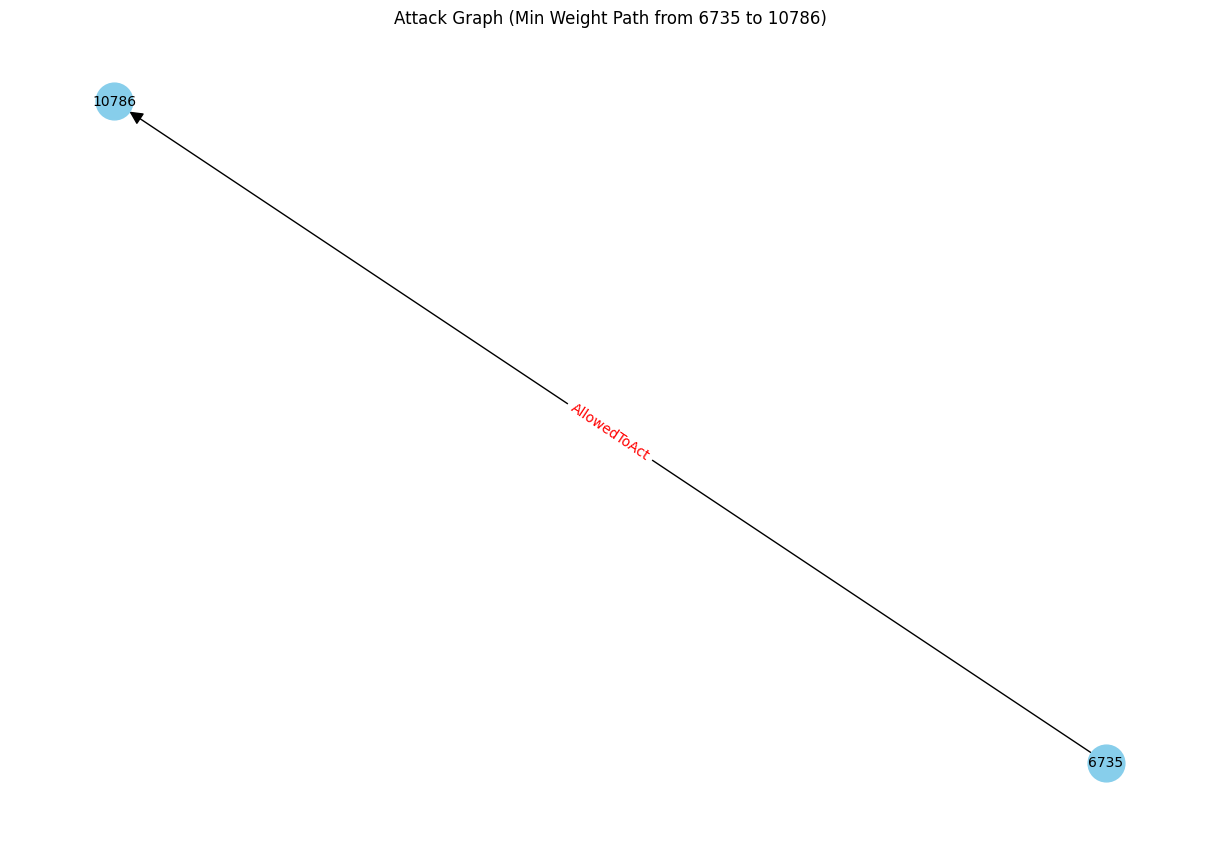

In [ ]:
# prompt: using min_weight_row plot the attack graph using networkx

import matplotlib.pyplot as plt

# Create a graph for the attack path
attack_graph = nx.DiGraph()

# Add nodes from the min_weight_row path
path_nodes = min_weight_row['path']
for node_id in path_nodes:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the min_weight_row path
for i in range(len(path_nodes) - 1):
    start_node = path_nodes[i]
    end_node = path_nodes[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
pos = nx.spring_layout(attack_graph)  # You can choose a different layout

plt.figure(figsize=(12, 8))
nx.draw(attack_graph, pos, with_labels=False, node_size=700, node_color='skyblue', font_size=10, arrowsize=20)

# Add node labels
node_labels = nx.get_node_attributes(attack_graph, 'label')
nx.draw_networkx_labels(attack_graph, pos, labels=node_labels, font_size=10)

# Add edge labels
edge_labels = nx.get_edge_attributes(attack_graph, 'label')
nx.draw_networkx_edge_labels(attack_graph, pos, edge_labels=edge_labels, font_color='red')

plt.title(f"Attack Graph (Min Weight Path from {min_weight_row['source']} to {min_weight_row['target']})")
plt.show()

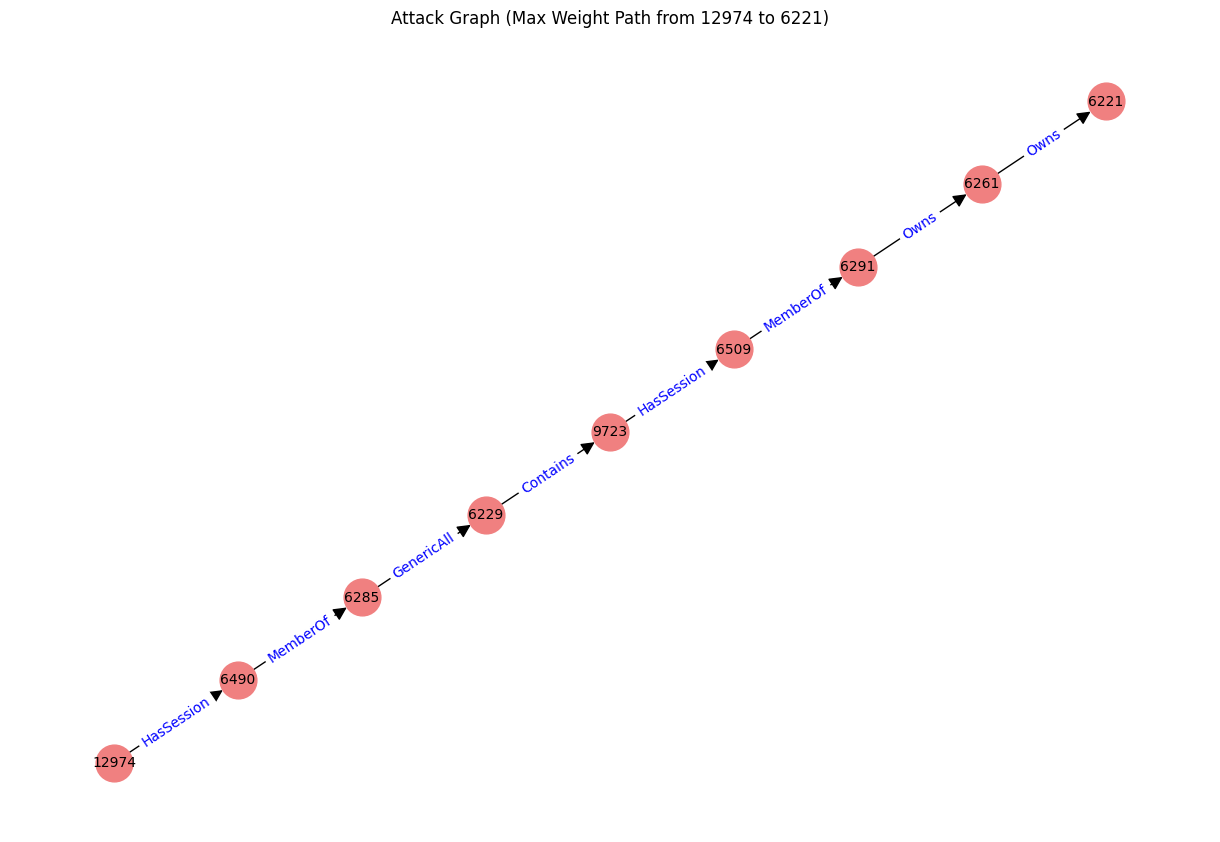

In [ ]:
# prompt: using max_weight_row plot the attack graph using networkx starting at the bottom left and ending up top right

import matplotlib.pyplot as plt
# Create a graph for the attack path using the max_weight_row
attack_graph_max = nx.DiGraph()

# Add nodes from the max_weight_row path
path_nodes_max = max_weight_row['path']
for node_id in path_nodes_max:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph_max.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the max_weight_row path
for i in range(len(path_nodes_max) - 1):
    start_node = path_nodes_max[i]
    end_node = path_nodes_max[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph_max.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
# Use a different layout that allows positioning
pos_max = {}
num_nodes = len(path_nodes_max)
# Simple linear positioning from bottom left to top right
for i, node_id in enumerate(path_nodes_max):
    pos_max[node_id] = (i, i) # Positions nodes diagonally

plt.figure(figsize=(12, 8))
nx.draw(attack_graph_max, pos_max, with_labels=False, node_size=700, node_color='lightcoral', font_size=10, arrowsize=20)

# Add node labels
node_labels_max = nx.get_node_attributes(attack_graph_max, 'label')
nx.draw_networkx_labels(attack_graph_max, pos_max, labels=node_labels_max, font_size=10)

# Add edge labels
edge_labels_max = nx.get_edge_attributes(attack_graph_max, 'label')
nx.draw_networkx_edge_labels(attack_graph_max, pos_max, edge_labels=edge_labels_max, font_color='blue')

plt.title(f"Attack Graph (Max Weight Path from {max_weight_row['source']} to {max_weight_row['target']})")
plt.show()

In [ ]:
/1


<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
/tmp/ipython-input-94-691856829.py:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  1()


TypeError: 'int' object is not callable

In [ ]:
df_shortest_paths_with_weight

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
min_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].min().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_min = pd.merge(df_shortest_paths_with_weight, min_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Minimum Weight: {row['total_weight']}, Path: {row['path']}")


In [ ]:
# prompt: for each source find MAXIMUM weight and target. only save the max results in result_max

import pandas as pd
# Group by source and find the maximum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the maximum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
for index, row in result_max.iterrows():
  print(f"Source: {row['source']}, Target: {row['target']}, Maximum Weight: {row['total_weight']}, Path: {row['path']}")

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Max Weight: {row['total_weight']}, Path: {row['path']}")
# df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
# df_shortest_paths_with_weight

In [ ]:
# prompt: for each source IN df_shortest_paths_with_weight find maximum weight and target AND PATH. if weight is the same print out all instances

# Iterate through each unique source node
for source_node in df_shortest_paths_with_weight['source'].unique():
    # Filter the DataFrame for the current source node
    source_df = df_shortest_paths_with_weight[df_shortest_paths_with_weight['source'] == source_node].copy()

    # Find the maximum weight for this source
    max_weight_for_source = source_df['total_weight'].max()

    # Filter for rows with the maximum weight for this source
    max_weight_paths = source_df[source_df['total_weight'] == max_weight_for_source]

    # Print the results for the current source
    print(f"\nSource: {source_node}")
    print(f"Maximum Weight for this source: {max_weight_for_source}")
    print("Paths with maximum weight:")
    for index, row in max_weight_paths.iterrows():
        print(f"  Target: {row['target']}, Path: {row['path']}")

In [ ]:
result_min

In [ ]:
result_max

In [ ]:
# prompt: show me where source appears the most within the results_max dataframe. is ther one source that appears most

source_counts = result_max['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts)

most_frequent_source = source_counts.index[0]
most_frequent_count = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
source_counts_min = result_min['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts_min)

most_frequent_source_min = source_counts.index[0]
most_frequent_count_min = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count_min > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
# prompt: convert result into a DataFrame

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
df_shortest_paths_with_weight

,source,target,path,total_weight
0,15,301,"[15, 301]",2
1,15,318,"[15, 318]",2
2,26,331,"[26, 331]",2
3,26,341,"[26, 341]",2
4,26,357,"[26, 357]",2
5,26,405,"[26, 405]",2
6,26,444,"[26, 444]",2
7,26,448,"[26, 448]",2
8,27,392,"[27, 392]",2
9,29,481,"[29, 481]",2


In [ ]:
print(edges[edges['end'] == 301])

In [ ]:
shortest_paths_with_weight

In [ ]:
# prompt: for each node in shortest_paths_with_weight, find the minimum total_weight and the maxium total_weight, save it to a DataFrame

import pandas as pd
# Initialize a dictionary to store min and max weights for each target node
target_node_weights = {}

# Iterate through the shortest paths
for path_info in shortest_paths_with_weight:
    target_node = path_info['target']
    total_weight = path_info['total_weight']

    if target_node not in target_node_weights:
        target_node_weights[target_node] = {'min_weight': float('inf'), 'max_weight': float('-inf')}

    # Update min and max weights
    target_node_weights[target_node]['min_weight'] = min(target_node_weights[target_node]['min_weight'], total_weight)
    target_node_weights[target_node]['max_weight'] = max(target_node_weights[target_node]['max_weight'], total_weight)

# Convert the dictionary to a DataFrame
min_max_weights_df = pd.DataFrame.from_dict(target_node_weights, orient='index')
min_max_weights_df.index.name = 'target_node'
min_max_weights_df = min_max_weights_df.reset_index()

# Display the resulting DataFrame
print("\nMin and Max Total Weights for Each Target Node:")
min_max_weights_df

In [ ]:
# prompt: for each record in "for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path

# Find the path with the smallest total weight
min_weight_path_info = min(shortest_paths_with_weight, key=lambda item: item['total_weight'])

# Find the path with the largest total weight
max_weight_path_info = max(shortest_paths_with_weight, key=lambda item: item['total_weight'])

print("\nPath with the Smallest Combined Weight:")
print(f"Source: {min_weight_path_info['source']}, Target: {min_weight_path_info['target']}, Total Weight: {min_weight_path_info['total_weight']}, Path: {min_weight_path_info['path']}")

print("\nPath with the Largest Combined Weight:")
print(f"Source: {max_weight_path_info['source']}, Target: {max_weight_path_info['target']}, Total Weight: {max_weight_path_info['total_weight']}, Path: {max_weight_path_info['path']}")

In [ ]:
# prompt: for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path for the largest weight

# Function to calculate the total weight of a path
# def calculate_path_weight(graph, path):
#     total_weight = 0
#     for i in range(len(path) - 1):
#         # Add node weight
#         total_weight += graph.nodes[path[i]].get('weight', 0)
#         # Add edge weight
#         total_weight += graph[path[i]][path[i+1]].get('weight', 0)
#     # Add the weight of the last node in the path
#     if path:
#         total_weight += graph.nodes[path[-1]].get('weight', 0)
#     return total_weight

# all_path_weights = {}

# # Iterate through each source and its paths in shortest_paths_filtered
# for source, paths_from_source in shortest_paths_list.items():
#     all_path_weights[source] = {}
#     # Iterate through each target and its path
#     for target, path in paths_from_source.items():
#         # Calculate the weight of the path using the original graph G
#         weight = calculate_path_weight(G, path)
#         all_path_weights[source][target] = weight

# # Find the smallest and largest combined weights
# min_weight = float('inf')
# max_weight = float('-inf')
# largest_weight_path = None
# largest_weight_source = None
# largest_weight_target = None

# for source, paths_from_source in all_path_weights.items():
#     for target, weight in paths_from_source.items():
#         if weight < min_weight:
#             min_weight_source = source
#             min_weight_target = target
#             min_weight_path = shortest_paths_filtered[source][target]
#             min_weight = weight
#         if weight > max_weight:
#             max_weight = weight
#             largest_weight_source = source
#             largest_weight_target = target
#             largest_weight_path = shortest_paths_filtered[source][target]

# print(f"Smallest combined weight: {min_weight}")
# print(f"Path for the smallest weight: {min_weight_path}")
# print(f"Source for the smallest weight path: {min_weight_source}")
# print(f"Target for the smallest weight path: {min_weight_target}")
# print(f"Largest combined weight: {max_weight}")
# print(f"Path for the largest weight: {largest_weight_path}")
# print(f"Source for the largest weight path: {largest_weight_source}")
# print(f"Target for the largest weight path: {largest_weight_target}")

In [ ]:

print(nodes[nodes['id'] == 111])
print(nodes[nodes['id'] == 8])
print(nodes[nodes['id'] == 26])
#print(nodes[nodes['id'] == 444])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

In [ ]:
selected_nodes

In [ ]:
selected_nodes

In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
shortest_paths

In [ ]:
shortest_paths_filtered

In [ ]:
# prompt: can you display the combined weight from the shortest_paths and display the path with the max weight

# Function to calculate the total weight of a path
def calculate_path_weight(graph, path):
    total_weight = 0
    # Add the weight of the starting node
    if path:
        total_weight += graph.nodes[path[0]].get('weight', 0) # Get node weight
    # Add the weight of the edges and the weights of subsequent nodes
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # Add edge weight
        total_weight += graph.edges[u, v].get('weight', 0) # Get edge weight
        # Add weight of the next node
        total_weight += graph.nodes[v].get('weight', 0) # Get node weight
    return total_weight

max_weight = -1
max_path = None

# Iterate through the filtered shortest paths and calculate total weights
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        current_weight = calculate_path_weight(G, path)
#        print(f"Path from {source} to {target}: {path}, Combined Weight: {current_weight}")
        if current_weight > max_weight:
            max_weight = current_weight
            max_path = path

print(f"\nPath with the maximum combined weight: {max_path}")
print(f"Maximum combined weight: {max_weight}")

In [ ]:
max_path
max_path = pd.DataFrame(max_path)
max_path.head()


In [ ]:
rename = {0: 'id'}
max_path = max_path.rename(columns=rename)
max_path

In [ ]:
# prompt: get label from nodes where id=max_path['id']

# Assuming max_path is a DataFrame with an 'id' column representing the node IDs in the max path
# and nodes is a DataFrame with 'id' and 'properties' columns.

# Get the list of node IDs from the max_path DataFrame
max_path_node_ids = max_path['id'].tolist()

# Filter the nodes DataFrame to get only the nodes that are in the max_path
nodes_in_max_path = nodes[nodes['id'].isin(max_path_node_ids)].copy()

# Now, extract the 'name' property from the 'properties' column for these nodes
# Use .loc to avoid SettingWithCopyWarning
# We use a lambda function with .apply to safely access nested dictionary keys.
max_path_node_labels = nodes_in_max_path.loc[:, 'properties'].apply(lambda x: x.get('name', ''))

print("Labels of nodes in the max path:")
print(max_path_node_labels.tolist())


In [ ]:
max_path

ignore from here


In [ ]:
vertices = nodes['id'].tolist()
vertices


In [ ]:
adj_list=adj.values.tolist()
len(adj_list)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def createAdjacencyMatrix(vertices,edges):
  noofvertices=len(vertices)
  adjM=[]
  while(len(adjM)<noofvertices):
    temp=[]
    for i in range(noofvertices):
      temp.append(0)
    adjM.append(temp)
  for edge in edges:
    i=edge[0]
    j=edge[1]
    if i>=noofvertices or j>=noofvertices or i<0 or j<0:
      print(f"Not a Proper Input in Edge {i},{j}")
    else:
      adjM[i][j]=1
      adjM[j][i]=1
#  G=nx.Graph()
#  G.add_edges_from(edges)
#  nx.draw_networkx(G)
#  plt.show()
  return adjM
vertices = vertices
edges = adj_list
adjM=createAdjacencyMatrix(vertices,edges)


In [ ]:
#adjM.shape
import numpy as np
len(adjM)
arr = np.array(adjM)

newarr = arr.reshape(10075, 10075)

print(newarr)

In [ ]:
def create_adjacency_matrix(V, edges):
    # Initialize an empty V x V matrix with all zeros
    matrix = [[0] * V for _ in range(V)]

    # Populate the matrix based on the edges
    for edge in edges:
        u, v = edge
        matrix[u][v] = 1
#       matrix[v][u] = 1  # Undirected graph

    return matrix
V1 = len(adj)
edges1 = adj[['start', 'end']].values.tolist()
adj_matrix1 = create_adjacency_matrix(V1, edges1)
for row in adj_matrix1:
    print(row)
print()

In [ ]:
type(adj)

In [81]:
import pandas as pd

# Initialize an empty DataFrame to store selected records
selected_records = pd.DataFrame(columns=filtered_nodes_regex.columns)

# Iterate through each row of the filtered_nodes_regex DataFrame
for index, row in filtered_nodes_regex.iterrows():
    properties = row['properties']

    # Check if 'properties' is a dictionary and contains 'highvalue' and if 'highvalue' is True
    if isinstance(properties, dict) and 'highvalue' in properties and properties['highvalue'] == True:
        # Append the entire row to the selected_records DataFrame
        selected_records = pd.concat([selected_records, pd.DataFrame([row])], ignore_index=True)

# Display the selected_records DataFrame
print("Selected records where 'highvalue' is True:")
display(selected_records)

Selected records where 'highvalue' is True:


,id,properties,type,l1,l2,l3,weight
